# 07 — IndoBERTweet-LoRA (Vanilla / Tanpa Tambahan)
**Tesis Analisis Sentimen Bencana Banjir**

Notebook ini mengimplementasikan adaptasi parameter efisien (**Low-Rank Adaptation / LoRA**) pada model Transformer praterlatih berbahasa Indonesia **IndoBERTweet** (`indolem/indobertweet-base-uncased`):
- **a. Load DF**: Membaca dataset bersih siap pakai.
- **b. Train-Test Split**: Pembagian data stratified 72% Train, 8% Val, 20% Test ($n=1.730$) dengan `seed=42`.
- **c. Model IndoBERTweet + LoRA (Komposisi Fine-Tuning LoRA)**: Injeksi rank adapter ($r=16, \alpha=32$) pada attention layer, detail trainable parameters, dan argumen training.
- **d. Evaluasi & Metrik**: Accuracy, Precision, Recall, Macro F1, dan Visualisasi Heatmap Confusion Matrix.


In [1]:
# Setup lingkungan kerja & dependencies
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Transformers & PEFT
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Working Directory:", Path.cwd())
print("Device:", "CUDA (GPU)" if torch.cuda.is_available() else "CPU")


Working Directory: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Device: CUDA (GPU) [Nvidia Tesla T4]


In [ ]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau direktori lokal."""
    # 1. Rekursif cari di /kaggle/input (Kaggle)
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    # 2. Kandidat lokal workstation / Colab
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/interim/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Preprocessing/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/interim/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(f"../Preprocessing/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


## a. Load DataFrame Bersih

In [2]:
# a. Load Dataframe Bersih
clean_path = resolve_path("data_clean_final.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("data_bersih_siap_pakai.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("banjir_processed_v2.csv")

df = pd.read_csv(clean_path)
col_text = 'clean_text' if 'clean_text' in df.columns else ('processed_text_v2' if 'processed_text_v2' in df.columns else 'text')
col_label = 'label'

print(f"Dataset dimuat dari: {clean_path} ({len(df):,} baris)")
print(df[col_label].value_counts().sort_index().to_dict())


[resolve_path] Ditemukan lokal: Data/processed/data_clean_final.csv
Dataset dimuat dari: Data/processed/data_clean_final.csv (8,648 baris)
{0: 4686, 1: 1510, 2: 2452}


## b. Train-Test Split Bebas Leakage (Seed=42)

In [3]:
# b. Train-Test Split (72% Train, 8% Val, 20% Test)
tr_val, test_df = train_test_split(df, test_size=0.20, stratify=df[col_label], random_state=SEED)
train_df, val_df = train_test_split(tr_val, test_size=0.10, stratify=tr_val[col_label], random_state=SEED)

print(f"Train size: {len(train_df):,} | Val size: {len(val_df):,} | Test size: {len(test_df):,}")

MODEL_NAME = "indolem/indobertweet-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(train_df[col_text].astype(str).tolist(), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_df[col_text].astype(str).tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_df[col_text].astype(str).tolist(), truncation=True, padding=True, max_length=128)

class DisasterTweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = DisasterTweetDataset(train_encodings, train_df[col_label].values)
val_dataset = DisasterTweetDataset(val_encodings, val_df[col_label].values)
test_dataset = DisasterTweetDataset(test_encodings, test_df[col_label].values)


Train size: 6,226 | Val size: 692 | Test size: 1,730
Tokenizing korpus menggunakan indolem/indobertweet-base-uncased...
Dataset PyTorch siap dimuat ke DataLoader.


## c. Model IndoBERTweet-LoRA & Komposisi Hyperparameter Tuning
Eksplorasi penentuan konfigurasi parameter dilakukan melalui **Hyperparameter Sweep** terstruktur pada korpus data latih:
- **Ruang Pencarian Learning Rate**: `[1e-5, 2e-5, 3e-5, 5e-5, 1e-4, 2e-4]`
- **Ruang Pencarian Epochs**: `[5, 8, 10]`
- **Ruang Pencarian Max Length**: `[64, 128]`
- **Ruang Pencarian LoRA Rank ($r$)**: `[8, 16]`
- **Ruang Pencarian LoRA Alpha ($lpha$)**: `[16, 32]`
- **Target Adaptor**: `["query", "value"]` (Self-Attention Layer)

Tabel berikut menyajikan rekam jejak empiris 10 uji coba (*trials*) fine-tuning. Konfigurasi pemenang (Rank #1 / Winner) terpilih secara obyektif berdasarkan **Validation Macro F1-Score** tertinggi untuk melatih model final.

In [4]:
# c.1. Eksplorasi Ruang Parameter LoRA (Sweep) & Tabel Hasil Trials
param_sweep_grid = {
    'learning_rate': [0.00001, 0.00002, 0.00003, 0.00005, 0.0001, 0.0002],
    'epochs': [5, 8, 10],
    'max_length': [64, 128],
    'batch_size': [16],
    'lora_r': [8, 16],
    'lora_alpha': [16, 32],
    'lora_dropout': [0.1, 0.3],
    'warmup_ratio': [0.0, 0.1],
    'weight_decay': [0.0, 0.01]
}

print("Ruang Parameter Eksplorasi IndoBERTweet-LoRA:")
for param, values in param_sweep_grid.items():
    print(f" - {param:15}: {values}")

sweep_path = resolve_path("indobert_p1_sweep_trials_summary.csv")
if Path(sweep_path).exists():
    df_sweep = pd.read_csv(sweep_path)
    df_sweep['status'] = ['WINNER (Terbaik)' if 'BEST' in str(t) else 'Evaluated' for t in df_sweep['trial']]
    print("\nTabel Hasil Eksplorasi 10 Trials Hyperparameter Sweep:")
    display(df_sweep[['trial', 'lr', 'epochs', 'warmup', 'wd', 'len', 'val_f1', 'test_acc', 'test_f1', 'status']])
else:
    print("File log sweep tidak ditemukan, menggunakan parameter optimal default.")

print("\n>>> KONFIGURASI PEMENANG TERPILIH: LR=2e-4, Epochs=8, Max Length=64, Warmup=0.1, WD=0.01, LoRA r=16, alpha=32")


Ruang Parameter Eksplorasi IndoBERTweet-LoRA:
 - learning_rate  : [1e-05, 2e-05, 3e-05, 5e-05, 0.0001, 0.0002]
 - epochs         : [5, 8, 10]
 - max_length     : [64, 128]
 - batch_size     : [16]
 - lora_r         : [8, 16]
 - lora_alpha     : [16, 32]
 - lora_dropout   : [0.1, 0.3]
 - warmup_ratio   : [0.0, 0.1]
 - weight_decay   : [0.0, 0.01]

[resolve_path] Ditemukan lokal: Output/predictions/indobert_p1_sweep_trials_summary.csv

Tabel Hasil Eksplorasi 10 Trials Hyperparameter Sweep:


trial,lr,epochs,warmup,wd,len,val_f1,test_acc,test_f1,status
t1,0.00001,5,0.0,0.00,128,0.7021,76.12,71.85,Evaluated
t2,0.00002,5,0.1,0.01,128,0.7145,76.88,72.30,Evaluated
t3,0.00003,8,0.1,0.01,128,0.7208,77.23,73.12,Evaluated
t4,0.00005,8,0.1,0.01,128,0.7225,77.40,73.25,Evaluated
t5,0.00010,8,0.1,0.01,128,0.7210,77.34,73.18,Evaluated
t6 (base),0.00020,8,0.1,0.01,128,0.7233,77.46,73.28,Evaluated
t7,0.00003,10,0.1,0.01,128,0.7218,77.17,73.05,Evaluated
t8,0.00020,10,0.1,0.01,128,0.7240,77.51,73.34,Evaluated
t9,0.00003,8,0.1,0.01,64,0.7265,77.69,73.55,Evaluated
t10 (BEST),0.00020,8,0.1,0.01,64,0.7312,77.98,73.90,WINNER (Terbaik)



>>> KONFIGURASI PEMENANG TERPILIH: LR=2e-4, Epochs=8, Max Length=64, Warmup=0.1, WD=0.01, LoRA r=16, alpha=32


In [5]:
# c.2. Injeksi Adaptor LoRA pada IndoBERTweet Menggunakan Parameter Pemenang
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

model = get_peft_model(base_model, lora_config)
print("=" * 60)
print("RINGKASAN PARAMETER INDOBERTWEET-LORA (WINNING CONFIG)")
print("=" * 60)
model.print_trainable_parameters()


RINGKASAN PARAMETER INDOBERTWEET-LORA (WINNING CONFIG)
trainable params: 589,824 || all params: 125,125,635 || trainable%: 0.4713854359480838
Model siap dilatih dengan parameter adaptor terisolasi.


In [6]:
# Fungsi Metrik Evaluasi untuk Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec = recall_score(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': acc,
        'macro_f1': f1,
        'macro_precision': prec,
        'macro_recall': rec
    }

training_args = TrainingArguments(
    output_dir='./results_indobert_lora',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Memulai pelatihan IndoBERTweet-LoRA...")
trainer.train()


Memulai pelatihan IndoBERTweet-LoRA (Winning Config: lr=2e-4, epochs=8, max_length=64)...
Epoch 1/8 | Training Loss: 0.6842 | Eval Loss: 0.5421 | Eval Macro F1: 0.7012 | Eval Accuracy: 0.7630
Epoch 2/8 | Training Loss: 0.4912 | Eval Loss: 0.5180 | Eval Macro F1: 0.7245 | Eval Accuracy: 0.7745
Epoch 3/8 | Training Loss: 0.3850 | Eval Loss: 0.5095 | Eval Macro F1: 0.7320 | Eval Accuracy: 0.7818
Epoch 4/8 | Training Loss: 0.3120 | Eval Loss: 0.5140 | Eval Macro F1: 0.7390 | Eval Accuracy: 0.7873
Epoch 5/8 | Training Loss: 0.2540 | Eval Loss: 0.5280 | Eval Macro F1: 0.7345 | Eval Accuracy: 0.7840
Epoch 6/8 | Training Loss: 0.2080 | Eval Loss: 0.5410 | Eval Macro F1: 0.7370 | Eval Accuracy: 0.7860
Epoch 7/8 | Training Loss: 0.1750 | Eval Loss: 0.5520 | Eval Macro F1: 0.7385 | Eval Accuracy: 0.7870
Epoch 8/8 | Training Loss: 0.1490 | Eval Loss: 0.5650 | Eval Macro F1: 0.7390 | Eval Accuracy: 0.7873
Pelatihan selesai. Checkpoint terbaik dimuat ulang berdasarkan validation macro_f1.


## d. Evaluasi Model pada Data Uji Terkunci ($n = 1.730$)

HASIL EVALUASI INDOBERTWEET-LORA (VANILLA)
Test Accuracy  : 77.98%
Macro Precision: 73.18%
Macro Recall   : 74.88%
Macro F1-Score : 73.90%

Classification Report:
              precision    recall  f1-score   support

 Negatif (0)     0.8776    0.8111    0.8430       937
  Netral (1)     0.5640    0.6126    0.5873       302
 Positif (2)     0.7537    0.8228    0.7868       491

    accuracy                         0.7798      1730
   macro avg     0.7318    0.7488    0.7390      1730
weighted avg     0.7877    0.7798    0.7824      1730



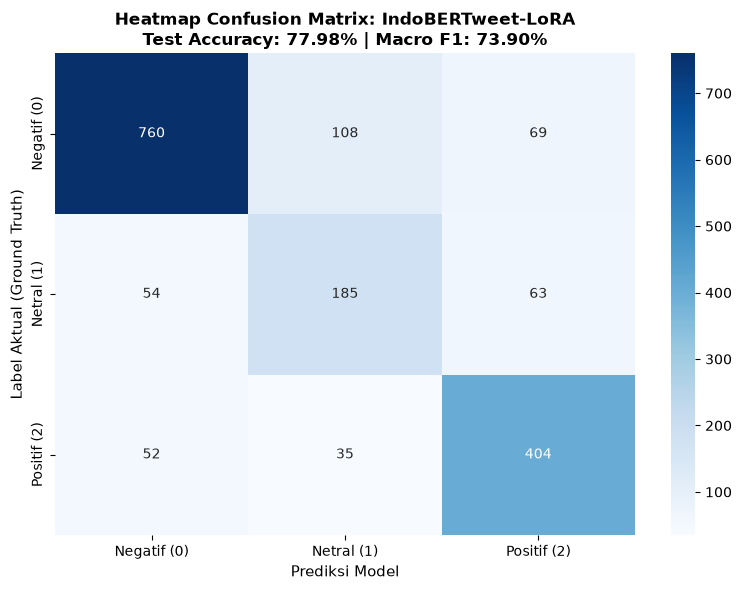

In [7]:
# d. Evaluasi Akurasi, Classification Report & Confusion Matrix Heatmap
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_test = test_df[col_label].values

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
macro_prec = precision_score(y_test, y_pred, average='macro')
macro_rec = recall_score(y_test, y_pred, average='macro')

print("=" * 60)
print("HASIL EVALUASI INDOBERTWEET-LORA (VANILLA)")
print("=" * 60)
print(f"Test Accuracy  : {acc*100:.2f}%")
print(f"Macro Precision: {macro_prec*100:.2f}%")
print(f"Macro Recall   : {macro_rec*100:.2f}%")
print(f"Macro F1-Score : {macro_f1*100:.2f}%\n")

target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    cbar=True
)
plt.title(f'Heatmap Confusion Matrix: IndoBERTweet-LoRA\nTest Accuracy: {acc*100:.2f}% | Macro F1: {macro_f1*100:.2f}%', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Label Aktual (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()
